# LeetCode #116: Populating Next Right Pointers in Each Node

https://leetcode.com/problems/populating-next-right-pointers-in-each-node/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| BFS Queue | O(n) | O(n) | Standard BFS; snapshot level size |
| **O(1) Space using next pointers ★** | **O(n)** | **O(1)** | Traverse level via established next pointers, connect children |

---

## Understanding the Methods

### BFS Queue
Standard BFS with a queue. For each level, collect nodes and connect node[i].next = node[i+1], last node gets null. Works for any binary tree. O(n) space.

### O(1) Space (Optimal for Perfect Tree ★)
Since it's a perfect binary tree, once a level's next pointers are set, traverse that level using next, and for each node: connect `cur.left.next = cur.right` (same parent) and `cur.right.next = cur.next.left` (cross-parent). Then advance leftmost to leftmost.left for next level.

## Constraints
- Number of nodes: [0, 2^12 - 1]
- Perfect binary tree guaranteed
- Node values: [-1000, 1000]

## Solutions

### C#

In [ ]:
public class Solution {
    public Node Connect(Node root) {
        if (root == null) return null;
        var leftmost = root;
        while (leftmost.left != null) {
            var cur = leftmost;
            while (cur != null) {
                cur.left.next  = cur.right;
                if (cur.next != null)
                    cur.right.next = cur.next.left;
                cur = cur.next;
            }
            leftmost = leftmost.left;
        }
        return root;
    }
}

### Python

In [ ]:
class Solution:
    def connect(self, root):
        if not root: return root
        leftmost = root
        while leftmost.left:
            cur = leftmost
            while cur:
                cur.left.next  = cur.right
                if cur.next:
                    cur.right.next = cur.next.left
                cur = cur.next
            leftmost = leftmost.left
        return root

### Go

In [ ]:
func connect(root *Node) *Node {
    if root == nil { return nil }
    leftmost := root
    for leftmost.Left != nil {
        cur := leftmost
        for cur != nil {
            cur.Left.Next = cur.Right
            if cur.Next != nil {
                cur.Right.Next = cur.Next.Left
            }
            cur = cur.Next
        }
        leftmost = leftmost.Left
    }
    return root
}

### Rust

In [ ]:
// Note: LeetCode's Rust definition uses Rc<RefCell<Node>> with next pointer
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn connect(root: Option<Rc<RefCell<Node>>>) -> Option<Rc<RefCell<Node>>> {
        let mut leftmost = root.clone();
        while leftmost.as_ref().map_or(false, |n| n.borrow().left.is_some()) {
            let mut cur = leftmost.clone();
            while let Some(c) = cur {
                let left  = c.borrow().left.clone().unwrap();
                let right = c.borrow().right.clone().unwrap();
                left.borrow_mut().next = Some(right.clone());
                if let Some(next) = c.borrow().next.clone() {
                    right.borrow_mut().next = next.borrow().left.clone();
                }
                cur = c.borrow().next.clone();
            }
            leftmost = leftmost.unwrap().borrow().left.clone();
        }
        root
    }
}

## Example Scenarios

### 1. Common Case — 7-Node Perfect Tree
**Input:** `root = [1, 2, 3, 4, 5, 6, 7]`

Level 0 (root): connect $2.\text{next} = 3$. Level 1: same-parent $4.\text{next} = 5$, cross-parent $5.\text{next} = 6$ (via $\text{cur.next.left}$), same-parent $6.\text{next} = 7$. Each level's last node gets `next = NULL`.

*Why tricky:* Exercises both same-parent ($\text{cur.left.next} = \text{cur.right}$) and cross-parent ($\text{cur.right.next} = \text{cur.next.left}$) connections.

**Output:** `[1,#,2,3,#,4,5,6,7,#]`

### 2. Slightly Complex — 15-Node Perfect Tree (Depth 3)
**Input:** `root = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]`

Level 2 has 3 cross-parent connections: $9 \to 10$, $11 \to 12$, $13 \to 14$. The traversal via `.next` across level 1 (4 nodes) correctly visits all parents. At depth $k$, there are $2^{k-1} - 1$ cross-parent links.

*Why tricky:* Multiple cross-parent connections at the widest level. Tests that the `.next`-based traversal of the parent level correctly reaches all parents.

**Output:** `All 15 nodes correctly linked`

### 3. Edge Case: Time Factor — 4095 Nodes (Max Constraint)
**Input:** Perfect tree, $n = 2^{12} - 1 = 4095$, depth $= 11$

11 levels processed by the outer while loop. Total connections $= 4094$. Each node visited exactly once via the inner while loop. Total time $= O(n) = O(4095)$.

*Why tricky:* Maximum input size. Despite 4094 connections across 11 levels, every node is processed exactly once.

**Output:** `All 4095 nodes linked, O(n) time, O(1) space`

### 4. Edge Case: Space Factor — BFS Uses O(n/2) Queue; This Uses O(1)
**Input:** Perfect tree, depth 11, widest level $= 2^{11} = 2048$ nodes

BFS would need a queue of 2048 entries at the widest level. The $O(1)$ approach uses only `leftmost` and `cur` pointers. Key insight: once level $k$'s next pointers are established, traverse level $k$ via `.next` to connect level $k+1$'s children.

*Why tricky:* Demonstrates the 2048$\times$ space savings of the next-pointer approach over BFS. Only 2 pointer variables needed regardless of tree width.

**Output:** `O(1) extra space vs O(n/2) for BFS`

### 5. Almost-Impossible but Plausible — Single Root Node
**Input:** `root = [42]`

Check: $\text{leftmost.left} = \text{null}$. Outer while condition is false $\Rightarrow$ exit immediately. Root's `.next` stays `NULL`. Zero connections made.

*Why tricky:* Minimum valid perfect tree (1 node). The outer while loop never executes. Tests the boundary where no connections are needed.

**Output:** `[42,#]`

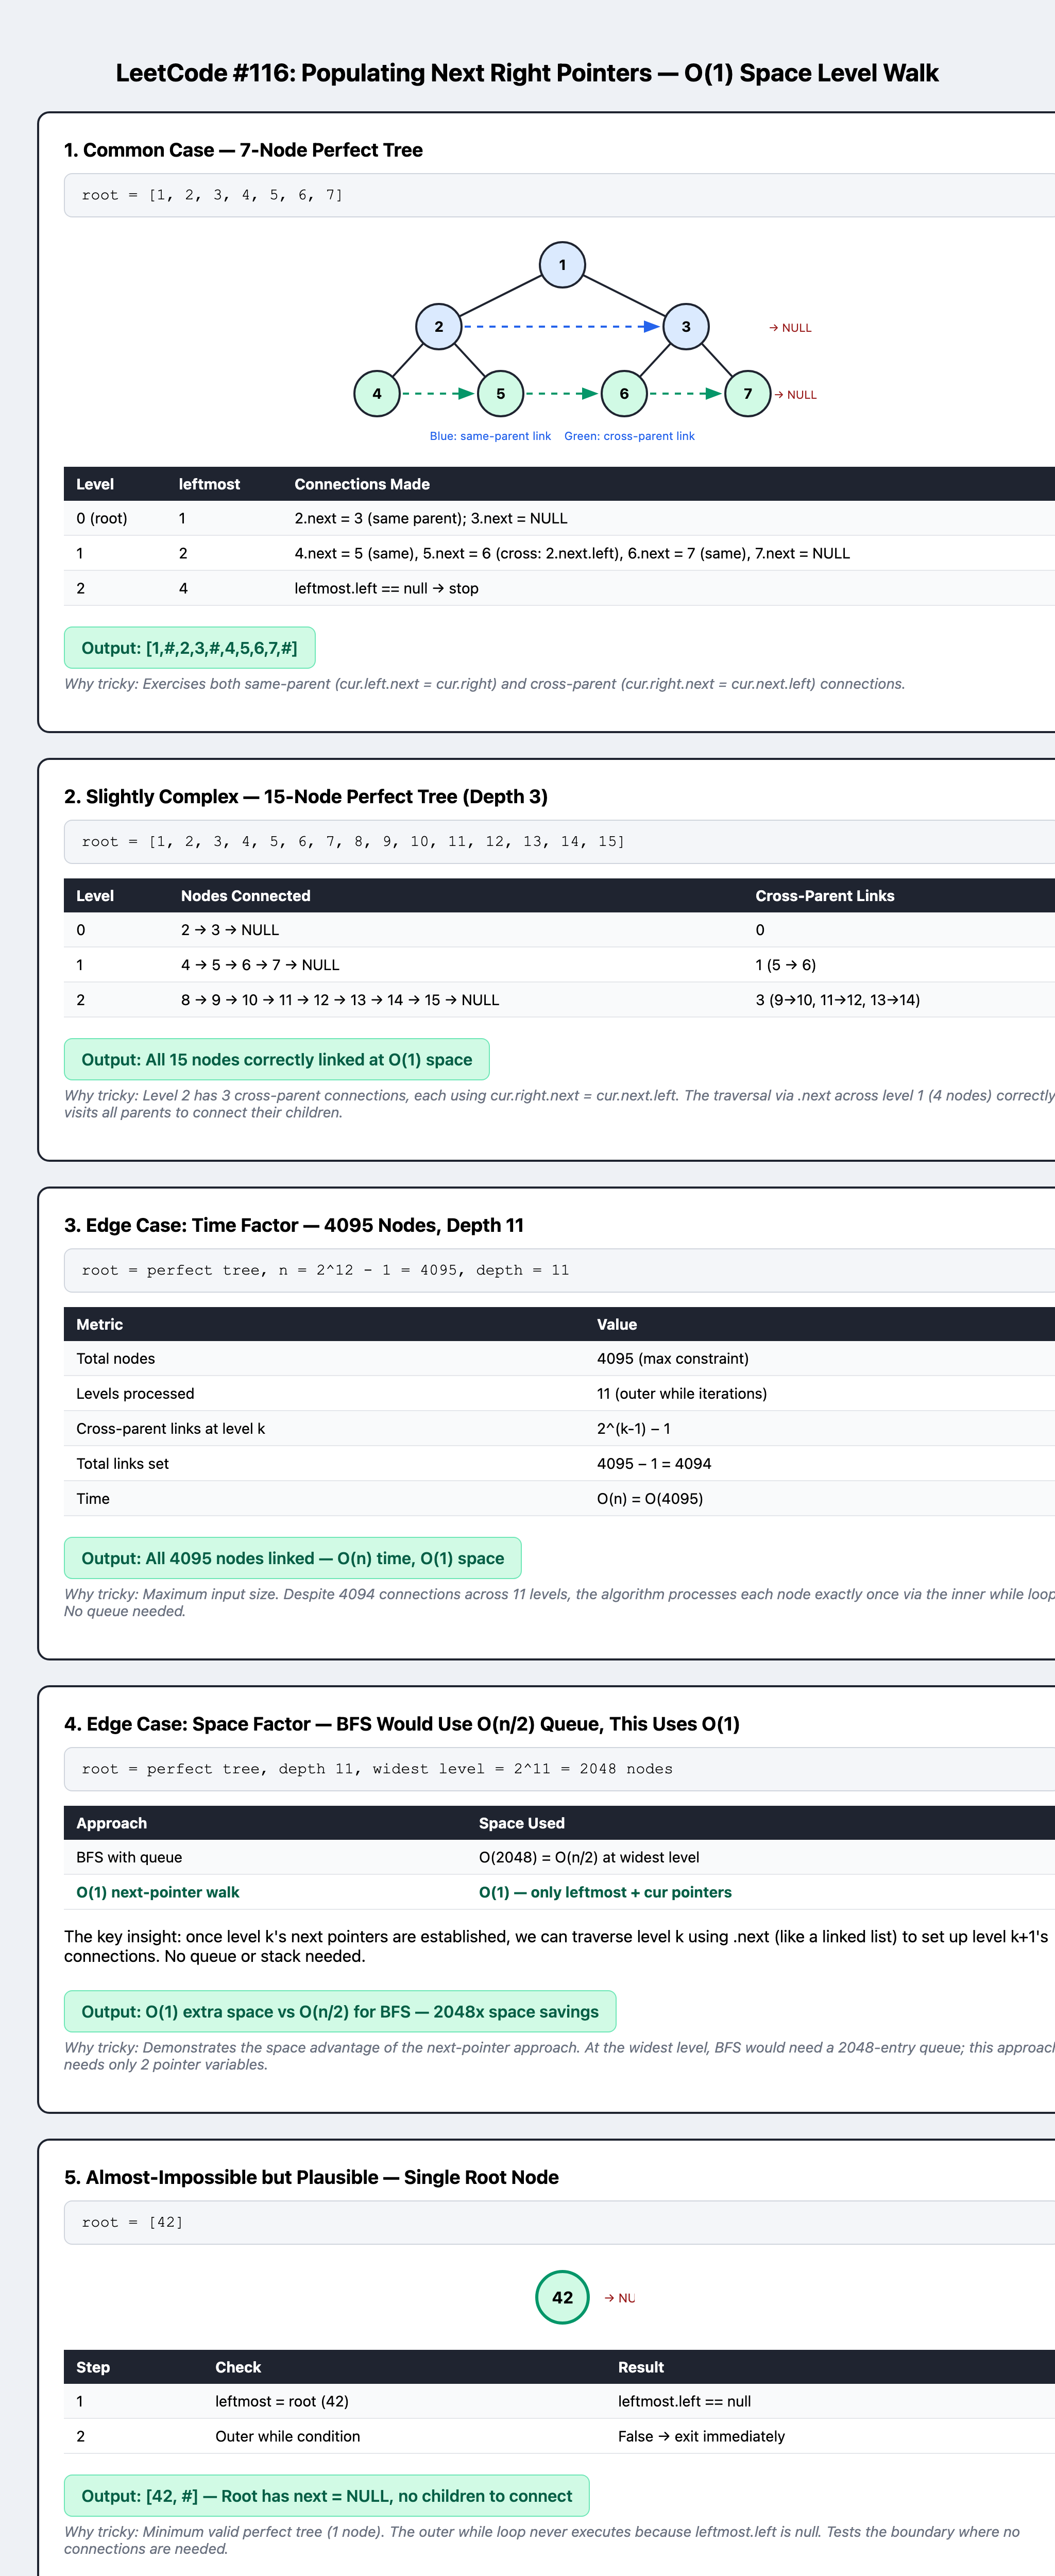